In [1]:
# ===== ИМПОРТЫ =====
import os, random, json, numpy as np, matplotlib.pyplot as plt, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

# ===== НАСТРОЙКИ =====
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

SEED = 42; set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")

# ===== ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ =====
def accuracy_from_logits(logits, y_true):
    return (torch.argmax(logits, dim=1) == y_true).float().mean().item()

def plot_history(history, title=""):
    epochs = range(1, len(history["train_loss"])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.plot(epochs, history["train_loss"], label="train"); plt.plot(epochs, history["val_loss"], label="val"); plt.title("Loss"); plt.legend(); plt.grid()
    plt.subplot(1,2,2); plt.plot(epochs, history["train_acc"], label="train"); plt.plot(epochs, history["val_acc"], label="val"); plt.title("Accuracy"); plt.legend(); plt.grid()
    plt.suptitle(title); plt.tight_layout(); plt.show()

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# ===== ДАННЫЕ =====
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,))])

train_full = torchvision.datasets.EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)
test_ds = torchvision.datasets.EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)

print(f"Classes: {len(train_full.classes)}, Train: {len(train_full)}, Test: {len(test_ds)}")

# ===== SPLIT + DATALOADER =====
BATCH_SIZE = 256 if device.type=="cuda" else 64
NUM_WORKERS = 0 if os.name=="nt" else 2

val_size = int(len(train_full)*0.1)
train_ds, val_ds = random_split(train_full, [len(train_full)-val_size, val_size], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")

x_batch, y_batch = next(iter(train_loader))
print(f"Batch: {x_batch.shape}, {y_batch.shape}")

Classes: 47, Train: 112800, Test: 18800
Batch: torch.Size([256, 1, 28, 28]), torch.Size([256])


In [3]:
# ===== МОДЕЛЬ MLP =====
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(128,), num_classes=47, dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm: layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0: layers.append(nn.Dropout(dropout_p))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

# ===== ЦИКЛЫ =====
def train_epoch(model, loader, opt, crit, dev):
    model.train(); loss_sum, acc_sum, n = 0,0,0
    for x,y in loader:
        x,y = x.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        logits = model(x); loss = crit(logits,y)
        loss.backward(); opt.step()
        loss_sum += loss.item(); acc_sum += accuracy_from_logits(logits,y); n+=1
    return loss_sum/n, acc_sum/n

@torch.no_grad()
def evaluate(model, loader, crit, dev):
    model.eval(); loss_sum, acc_sum, n = 0,0,0
    for x,y in loader:
        x,y = x.to(dev), y.to(dev)
        logits = model(x); loss = crit(logits,y)
        loss_sum += loss.item(); acc_sum += accuracy_from_logits(logits,y); n+=1
    return loss_sum/n, acc_sum/n

# ===== EARLY STOPPING =====
class EarlyStopping:
    def __init__(self, patience=5): self.patience=patience; self.best=None; self.state=None; self.cnt=0
    def step(self, score, model):
        if self.best is None or score > self.best:
            self.best=score; self.state={k:v.cpu().clone() for k,v in model.state_dict().items()}; self.cnt=0; return False
        self.cnt+=1; return self.cnt>=self.patience
    def restore(self, model):
        if self.state: model.load_state_dict(self.state); print(" Best weights restored")

# ===== FIT =====
def fit(model, tr_loader, val_loader, opt, crit, dev, epochs=20, es=None, verbose=True):
    hist = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}
    for ep in range(1,epochs+1):
        tl,ta = train_epoch(model,tr_loader,opt,crit,dev)
        vl,va = evaluate(model,val_loader,crit,dev)
        hist["train_loss"].append(tl); hist["train_acc"].append(ta)
        hist["val_loss"].append(vl); hist["val_acc"].append(va)
        if verbose: print(f"Ep {ep:02d} | tr:{tl:.3f}/{ta:.3f} | val:{vl:.3f}/{va:.3f}")
        if es and es.step(va,model): print(f" EarlyStop @ {ep}"); es.restore(model); break
    return hist

In [4]:
# ===== ПАРАМЕТРЫ =====
INPUT_DIM, NUM_CLASSES, LR = 784, 47, 1e-3
EPOCHS_BASE, EPOCHS_ES = 20, 50
criterion = nn.CrossEntropyLoss()
os.makedirs("artifacts/figures", exist_ok=True)
print(" Folders ready")

 Folders ready



 E0
Ep 01 | tr:1.509/0.589 | val:1.128/0.683
Ep 02 | tr:1.013/0.708 | val:0.937/0.730
Ep 03 | tr:0.841/0.752 | val:0.804/0.767
Ep 04 | tr:0.736/0.777 | val:0.734/0.776
Ep 05 | tr:0.677/0.791 | val:0.691/0.789
Ep 06 | tr:0.632/0.803 | val:0.649/0.806
Ep 07 | tr:0.598/0.812 | val:0.634/0.805
Ep 08 | tr:0.573/0.817 | val:0.620/0.814
Ep 09 | tr:0.550/0.822 | val:0.600/0.817
Ep 10 | tr:0.531/0.828 | val:0.579/0.823
Ep 11 | tr:0.519/0.831 | val:0.576/0.823
Ep 12 | tr:0.508/0.833 | val:0.584/0.815
Ep 13 | tr:0.497/0.836 | val:0.571/0.816
Ep 14 | tr:0.484/0.840 | val:0.570/0.819
Ep 15 | tr:0.477/0.842 | val:0.575/0.823
Ep 16 | tr:0.468/0.844 | val:0.552/0.829
Ep 17 | tr:0.460/0.846 | val:0.561/0.822
Ep 18 | tr:0.454/0.848 | val:0.562/0.826
Ep 19 | tr:0.446/0.849 | val:0.558/0.827
Ep 20 | tr:0.442/0.851 | val:0.551/0.827


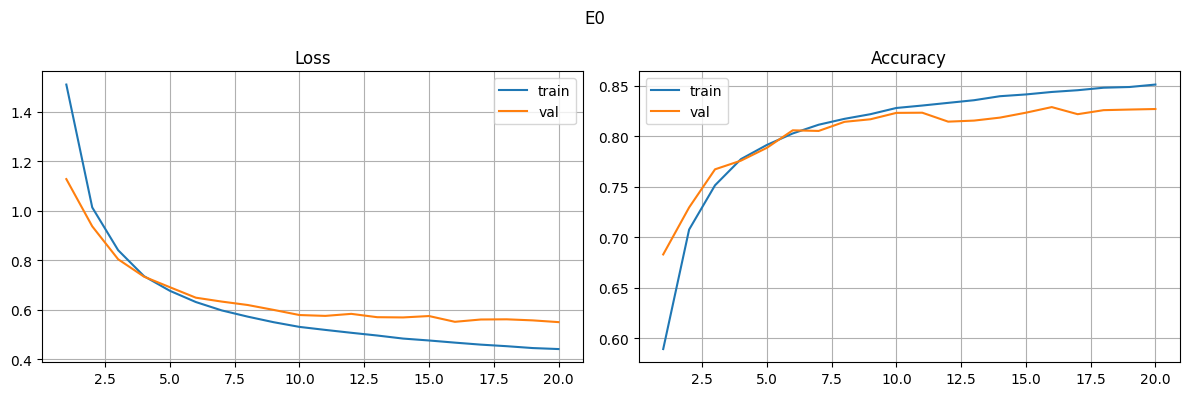


 E1
Ep 01 | tr:1.420/0.604 | val:0.964/0.711
Ep 02 | tr:0.800/0.756 | val:0.724/0.777
Ep 03 | tr:0.639/0.796 | val:0.616/0.812
Ep 04 | tr:0.564/0.817 | val:0.573/0.817
Ep 05 | tr:0.515/0.830 | val:0.532/0.832
Ep 06 | tr:0.480/0.838 | val:0.539/0.829
Ep 07 | tr:0.452/0.845 | val:0.538/0.828
Ep 08 | tr:0.432/0.851 | val:0.500/0.838
Ep 09 | tr:0.412/0.856 | val:0.489/0.843
Ep 10 | tr:0.394/0.862 | val:0.503/0.837
Ep 11 | tr:0.381/0.865 | val:0.483/0.846
Ep 12 | tr:0.367/0.870 | val:0.498/0.839
Ep 13 | tr:0.357/0.871 | val:0.499/0.834
Ep 14 | tr:0.343/0.875 | val:0.503/0.842
Ep 15 | tr:0.334/0.877 | val:0.491/0.844
Ep 16 | tr:0.323/0.881 | val:0.494/0.846
Ep 17 | tr:0.317/0.882 | val:0.502/0.844
Ep 18 | tr:0.309/0.885 | val:0.501/0.843
Ep 19 | tr:0.296/0.889 | val:0.503/0.847
Ep 20 | tr:0.295/0.889 | val:0.506/0.848


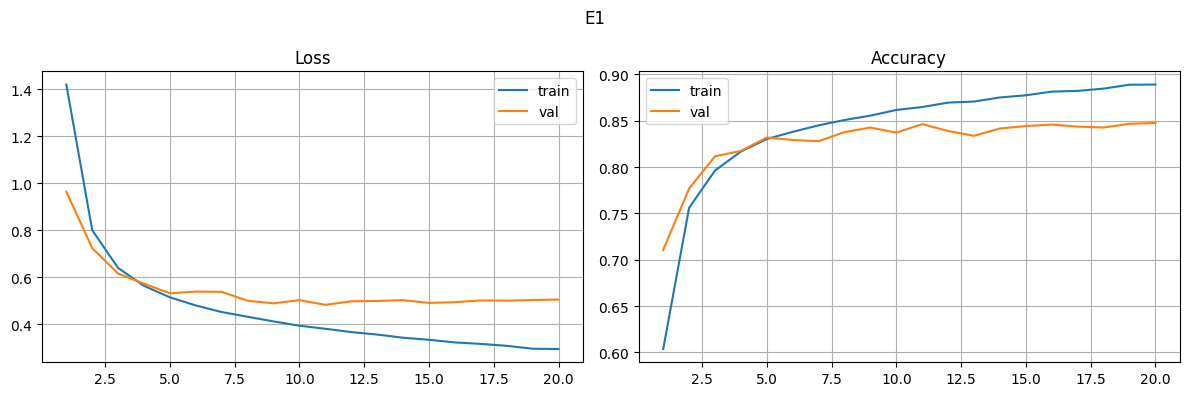


 E2
Ep 01 | tr:1.762/0.499 | val:0.981/0.706
Ep 02 | tr:1.106/0.665 | val:0.773/0.764
Ep 03 | tr:0.959/0.705 | val:0.699/0.784
Ep 04 | tr:0.884/0.725 | val:0.646/0.800
Ep 05 | tr:0.837/0.737 | val:0.620/0.805
Ep 06 | tr:0.798/0.747 | val:0.589/0.812
Ep 07 | tr:0.774/0.753 | val:0.572/0.814
Ep 08 | tr:0.755/0.758 | val:0.562/0.814
Ep 09 | tr:0.740/0.761 | val:0.542/0.827
Ep 10 | tr:0.722/0.768 | val:0.537/0.824
Ep 11 | tr:0.710/0.768 | val:0.535/0.824
Ep 12 | tr:0.706/0.771 | val:0.516/0.831
Ep 13 | tr:0.700/0.773 | val:0.519/0.829
Ep 14 | tr:0.686/0.776 | val:0.517/0.830
Ep 15 | tr:0.675/0.779 | val:0.513/0.831
Ep 16 | tr:0.672/0.780 | val:0.506/0.835
Ep 17 | tr:0.666/0.780 | val:0.507/0.832
Ep 18 | tr:0.660/0.783 | val:0.494/0.838
Ep 19 | tr:0.655/0.784 | val:0.495/0.837
Ep 20 | tr:0.648/0.786 | val:0.495/0.837


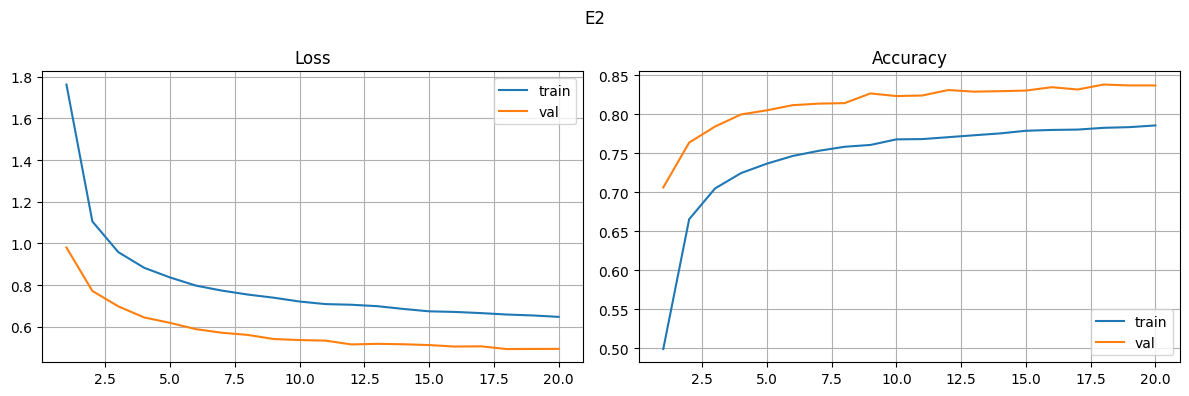


 E3
Ep 01 | tr:1.089/0.721 | val:0.630/0.807
Ep 02 | tr:0.531/0.828 | val:0.535/0.821
Ep 03 | tr:0.443/0.850 | val:0.487/0.839
Ep 04 | tr:0.393/0.864 | val:0.468/0.847
Ep 05 | tr:0.361/0.873 | val:0.496/0.833
Ep 06 | tr:0.334/0.880 | val:0.459/0.847
Ep 07 | tr:0.313/0.885 | val:0.468/0.845
Ep 08 | tr:0.296/0.890 | val:0.459/0.845
Ep 09 | tr:0.278/0.896 | val:0.459/0.849
Ep 10 | tr:0.268/0.898 | val:0.464/0.849
Ep 11 | tr:0.254/0.902 | val:0.473/0.848
Ep 12 | tr:0.242/0.907 | val:0.472/0.847
Ep 13 | tr:0.232/0.910 | val:0.509/0.843
Ep 14 | tr:0.222/0.914 | val:0.494/0.846
Ep 15 | tr:0.213/0.917 | val:0.494/0.849
Ep 16 | tr:0.205/0.920 | val:0.516/0.849
Ep 17 | tr:0.200/0.922 | val:0.537/0.839
Ep 18 | tr:0.192/0.924 | val:0.531/0.843
Ep 19 | tr:0.184/0.928 | val:0.555/0.839
Ep 20 | tr:0.178/0.928 | val:0.557/0.842


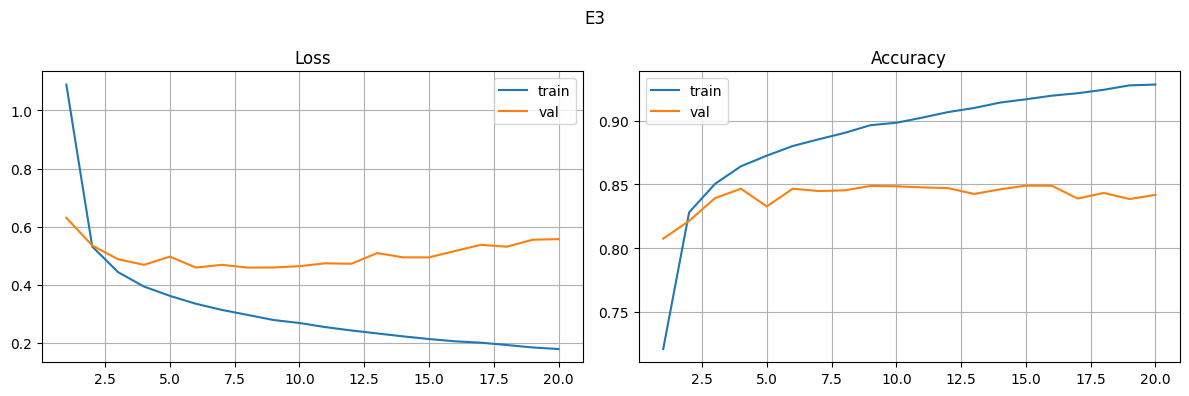


 E4
Ep 01 | tr:1.089/0.721 | val:0.630/0.807
Ep 02 | tr:0.531/0.828 | val:0.535/0.821
Ep 03 | tr:0.443/0.850 | val:0.487/0.839
Ep 04 | tr:0.393/0.864 | val:0.468/0.847
Ep 05 | tr:0.361/0.873 | val:0.496/0.833
Ep 06 | tr:0.334/0.880 | val:0.459/0.847
Ep 07 | tr:0.313/0.885 | val:0.468/0.845
Ep 08 | tr:0.296/0.890 | val:0.459/0.845
 EarlyStop @ 8
 Best weights restored


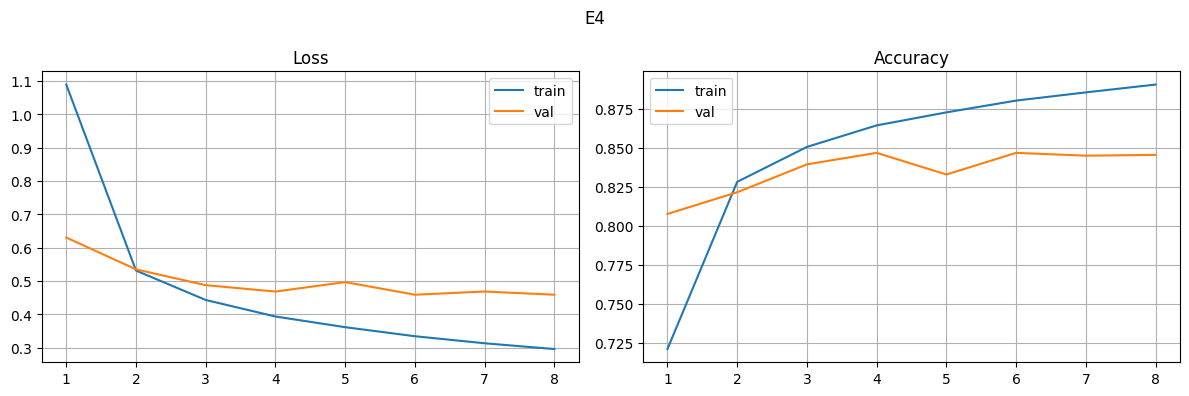

In [5]:
# ===== E0: 1 hidden layer =====
print("\n E0"); set_seed(SEED)
m0 = MLP(hidden_dims=(128,), num_classes=NUM_CLASSES).to(device)
h0 = fit(m0, train_loader, val_loader, optim.Adam(m0.parameters(),lr=LR), criterion, device, EPOCHS_BASE)
plot_history(h0,"E0")

# ===== E1: 2 hidden layers =====
print("\n E1"); set_seed(SEED)
m1 = MLP(hidden_dims=(256,128), num_classes=NUM_CLASSES).to(device)
h1 = fit(m1, train_loader, val_loader, optim.Adam(m1.parameters(),lr=LR), criterion, device, EPOCHS_BASE)
plot_history(h1,"E1")

# ===== E2: +Dropout =====
print("\n E2"); set_seed(SEED)
m2 = MLP(hidden_dims=(256,128), num_classes=NUM_CLASSES, dropout_p=0.3).to(device)
h2 = fit(m2, train_loader, val_loader, optim.Adam(m2.parameters(),lr=LR), criterion, device, EPOCHS_BASE)
plot_history(h2,"E2")

# ===== E3: +BatchNorm =====
print("\n E3"); set_seed(SEED)
m3 = MLP(hidden_dims=(256,128), num_classes=NUM_CLASSES, use_batchnorm=True).to(device)
h3 = fit(m3, train_loader, val_loader, optim.Adam(m3.parameters(),lr=LR), criterion, device, EPOCHS_BASE)
plot_history(h3,"E3")

# ===== E4: Best of E2/E3 + EarlyStopping =====
print("\n E4"); set_seed(SEED)
best_of_23 = m2 if max(h2["val_acc"]) >= max(h3["val_acc"]) else m3
cfg_dp = 0.3 if best_of_23 is m2 else 0.0
cfg_bn = False if best_of_23 is m2 else True
m4 = MLP(hidden_dims=(256,128), num_classes=NUM_CLASSES, dropout_p=cfg_dp, use_batchnorm=cfg_bn).to(device)
es = EarlyStopping(patience=4)
h4 = fit(m4, train_loader, val_loader, optim.Adam(m4.parameters(),lr=LR), criterion, device, EPOCHS_ES, es)
plot_history(h4,"E4")


 Saving artifacts...
 runs.csv
 Best: E3 | val_acc=0.8490
 best_model.pt
 best_config.json
 curves_best.png


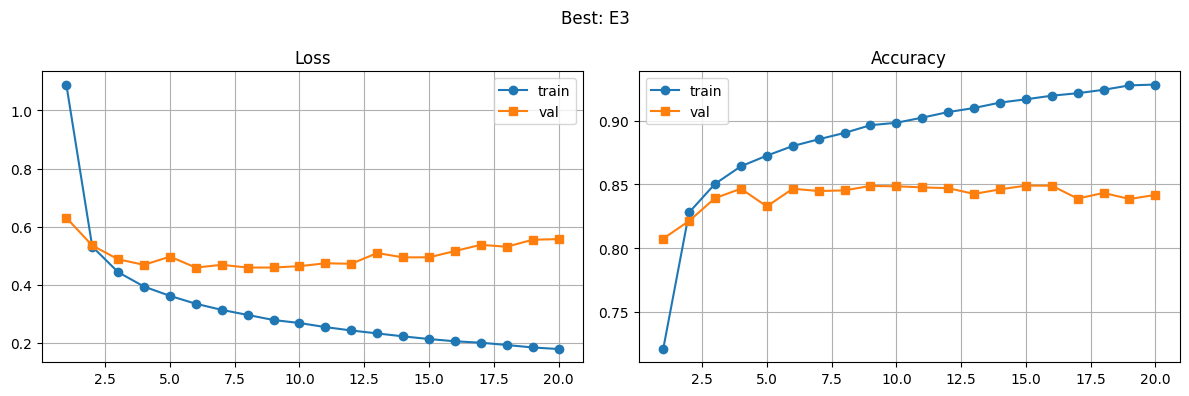


 Test Acc: 0.8430
 HW08 DONE!


In [6]:
# ===== СОХРАНЕНИЕ АРТЕФАКТОВ (ИСПРАВЛЕННОЕ) =====
print("\n Saving artifacts...")

# Таблица результатов
results = [
    {"experiment_id":"E0","dataset":"EMNIST","seed":SEED,"model_summary":"MLP(784→128→47)","dropout":0.0,"batchnorm":False,"epochs_trained":20,"best_val_accuracy":max(h0["val_acc"]),"best_val_loss":min(h0["val_loss"])},
    {"experiment_id":"E1","dataset":"EMNIST","seed":SEED,"model_summary":"MLP(784→256→128→47)","dropout":0.0,"batchnorm":False,"epochs_trained":20,"best_val_accuracy":max(h1["val_acc"]),"best_val_loss":min(h1["val_loss"])},
    {"experiment_id":"E2","dataset":"EMNIST","seed":SEED,"model_summary":"MLP+Dropout(0.3)","dropout":0.3,"batchnorm":False,"epochs_trained":20,"best_val_accuracy":max(h2["val_acc"]),"best_val_loss":min(h2["val_loss"])},
    {"experiment_id":"E3","dataset":"EMNIST","seed":SEED,"model_summary":"MLP+BatchNorm","dropout":0.0,"batchnorm":True,"epochs_trained":20,"best_val_accuracy":max(h3["val_acc"]),"best_val_loss":min(h3["val_loss"])},
    {"experiment_id":"E4","dataset":"EMNIST","seed":SEED,"model_summary":"MLP+Reg+EarlyStopping","dropout":cfg_dp,"batchnorm":cfg_bn,"epochs_trained":len(h4["val_acc"]),"best_val_accuracy":max(h4["val_acc"]),"best_val_loss":min(h4["val_loss"])}
]
pd.DataFrame(results).to_csv("artifacts/runs.csv", index=False)
print(" runs.csv")

# Лучшая модель
df = pd.DataFrame(results); best = df.loc[df["best_val_accuracy"].idxmax()]
print(f" Best: {best['experiment_id']} | val_acc={best['best_val_accuracy']:.4f}")
models = {"E0":m0,"E1":m1,"E2":m2,"E3":m3,"E4":m4}
torch.save(models[best["experiment_id"]].state_dict(), "artifacts/best_model.pt")
print(" best_model.pt")

# Конфиг
hidden = (128,) if best["experiment_id"]=="E0" else (256,128)
config = {"experiment_id":best["experiment_id"],"dataset":"EMNIST","seed":SEED,
          "architecture":{"input_dim":INPUT_DIM,"hidden_dims":hidden,"num_classes":NUM_CLASSES,"dropout_p":float(best["dropout"]),"use_batchnorm":bool(best["batchnorm"])},
          "training":{"optimizer":"Adam","lr":LR,"batch_size":BATCH_SIZE},
          "results":{"best_val_accuracy":float(best["best_val_accuracy"]),"best_val_loss":float(best["best_val_loss"])}}
with open("artifacts/best_config.json","w") as f: json.dump(config,f,indent=2)
print(" best_config.json")

# ===== ГРАФИК: СОХРАНЯЕМ ПЕРЕД show() =====
hist_map = {"E0":h0,"E1":h1,"E2":h2,"E3":h3,"E4":h4}
best_hist = hist_map[best["experiment_id"]]

# Строим график вручную (чтобы сохранить ДО show())
epochs = range(1, len(best_hist["train_loss"])+1)
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, best_hist["train_loss"], label="train", marker="o")
plt.plot(epochs, best_hist["val_loss"], label="val", marker="s")
plt.title("Loss"); plt.legend(); plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs, best_hist["train_acc"], label="train", marker="o")
plt.plot(epochs, best_hist["val_acc"], label="val", marker="s")
plt.title("Accuracy"); plt.legend(); plt.grid()

plt.suptitle(f"Best: {best['experiment_id']}")
plt.tight_layout()

#  СОХРАНЯЕМ ПЕРЕД show()!
plt.savefig("artifacts/figures/curves_best.png", dpi=300, bbox_inches="tight")
print(" curves_best.png")

# Теперь можно показать
plt.show()

# Test
test_l, test_a = evaluate(models[best["experiment_id"]], test_loader, criterion, device)
print(f"\n Test Acc: {test_a:.4f}\n HW08 DONE!")